In [3]:
import json
import warnings
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
TRAIN_RATIO = 0.70

CWD = Path.cwd().resolve()
PROJECT_ROOT = next(
    (candidate for candidate in (CWD, *CWD.parents)
     if (candidate / 'analyses').is_dir() and (candidate / 'bases').is_dir()),
    None
)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Nao foi possivel localizar a raiz do projeto.')

DATA_DIR = PROJECT_ROOT / 'analyses' / 'grupo1' / '01_dados'
OUTPUT_DIR = PROJECT_ROOT / 'analyses' / 'grupo1' / '02_modelos' / 'Random_Forest'

plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor': '#1a1a2e',
    'axes.edgecolor': '#444466',
    'axes.labelcolor': '#ccccee',
    'xtick.color': '#aaaacc',
    'ytick.color': '#aaaacc',
    'text.color': '#e0e0ff',
    'grid.color': '#2a2a4a',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'font.size': 10
})

# Random Forest — 02: Validação Walk-Forward
**Grupo 1 | Séries Temporais**

O modelo é avaliado em previsões diárias de um passo à frente, com janela de treino expansiva. A cada origem, o Random Forest é ajustado novamente usando apenas dados disponíveis até aquele momento. Os hiperparâmetros abaixo correspondem ao resultado selecionado no notebook 01; o teste final não participa da otimização.

As previsões, métricas e gráficos ficam disponíveis na sessão do notebook. Nenhum CSV ou JSON novo é criado.

Treino: 1996 observacoes | 2018-11-20 a 2024-05-07
Teste: 856 observacoes | 2024-05-08 a 2026-09-10
Features: 51 | Configuracao: {'n_estimators': 300, 'max_depth': 8, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 0.7}
Passo 200/856 concluido
Passo 400/856 concluido
Passo 600/856 concluido
Passo 800/856 concluido
Passo 856/856 concluido

Metricas no conjunto de teste (walk-forward):
MAE: USD 2,108.00 | RMSE: USD 2,901.95 | MAPE: 2.54% | R2: 0.9765
Vies: USD 240.77 | Desvio padrao: USD 2,891.94
Tempo: 3715.10 s (4340.06 ms por previsao)


,date,priceClose_real,priceClose_pred_RF,residuo_RF
0,2024-05-08,63049.959257,62515.635745,534.323512
1,2024-05-09,60792.776791,62050.176813,-1257.400022
2,2024-05-10,60793.709599,62367.047178,-1573.337578
3,2024-05-11,61448.394672,61176.434296,271.960376
4,2024-05-12,62901.447455,61898.182925,1003.264530


,semestre,n,MAE,RMSE
0,2024-S1,54,1283.584905,1756.570087
1,2024-S2,184,2472.367964,3374.100069
2,2025-S1,181,2042.151897,2835.431111
3,2025-S2,184,2323.385923,3064.053342
4,2026-S1,181,2128.098579,2835.559549
5,2026-S2,72,1359.747066,2072.616199


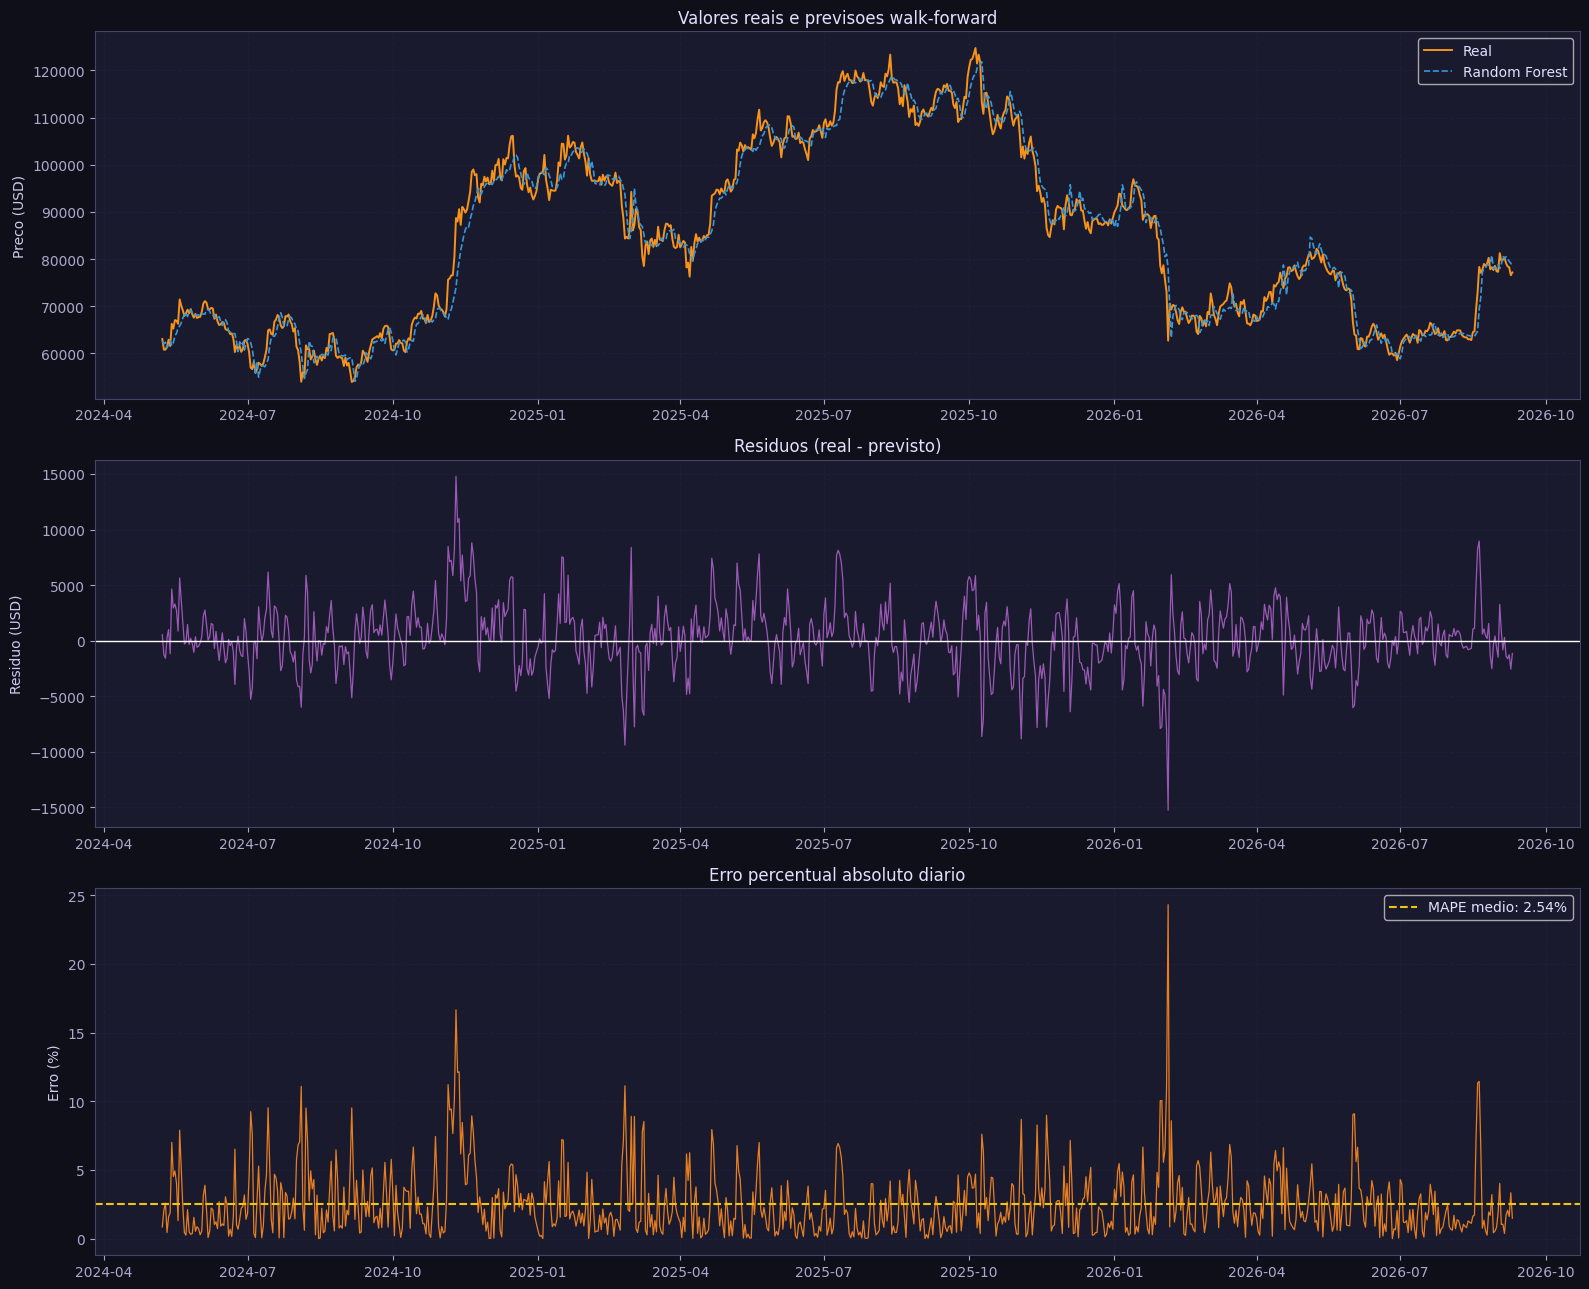


Metricas consolidadas mantidas em memoria:
{'modelo': 'Random_Forest', 'base': 'bitcoin', 'alvo': 'target', 'protocolo': 'walk-forward 1-step-ahead, janela expansiva', 'n_previsoes': 856, 'data_inicio_teste': '2024-05-08', 'data_fim_teste': '2026-09-10', 'MAE': 2108.001664698985, 'RMSE': 2901.947395887407, 'MAPE': 2.543061327746501, 'R2': 0.9764746745147209, 'Bias': 240.7708649311546, 'Std_residuo': 2891.941921805831, 'tempo_total_s': 3715.095542399911, 'random_state': 42, 'config_usada': {'n_estimators': 300, 'max_depth': 8, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 0.7}}


In [4]:
train_path = DATA_DIR / 'bitcoin_features_train.csv'
test_path = DATA_DIR / 'bitcoin_features_test.csv'
meta_path = DATA_DIR / 'feature_metadata.json'
train = pd.read_csv(train_path, parse_dates=['date']).sort_values('date').reset_index(drop=True)
test = pd.read_csv(test_path, parse_dates=['date']).sort_values('date').reset_index(drop=True)
with meta_path.open('r', encoding='utf-8') as file:
    meta = json.load(file)

FEATURE_COLS = meta['feature_cols']
TARGET_COL = meta['target_col']
if not np.isclose(meta['train_ratio'], TRAIN_RATIO):
    raise ValueError('A proporcao treino/teste diverge do protocolo 70/30.')
if len(train) != meta['n_train'] or len(test) != meta['n_test']:
    raise ValueError('Os arquivos de treino/teste nao correspondem aos metadados.')

X_train = train[FEATURE_COLS].astype(float)
y_train = train[TARGET_COL].astype(float)
X_test = test[FEATURE_COLS].astype(float)
y_test = test[TARGET_COL].astype(float)
if not np.isfinite(X_train.to_numpy()).all() or not np.isfinite(y_train.to_numpy()).all():
    raise ValueError('O treino contem valores ausentes ou nao finitos.')
if not np.isfinite(X_test.to_numpy()).all() or not np.isfinite(y_test.to_numpy()).all():
    raise ValueError('O teste contem valores ausentes ou nao finitos.')

RF_PARAMS = {
    'n_estimators': 300,
    'max_depth': 8,
    'min_samples_split': 2,
    'min_samples_leaf': 4,
    'max_features': 0.7
}
print(f"Treino: {len(train)} observacoes | {train['date'].min().date()} a {train['date'].max().date()}")
print(f"Teste: {len(test)} observacoes | {test['date'].min().date()} a {test['date'].max().date()}")
print(f'Features: {len(FEATURE_COLS)} | Configuracao: {RF_PARAMS}')

X_train_values = X_train.to_numpy()
y_train_values = y_train.to_numpy()
X_test_values = X_test.to_numpy()
y_test_values = y_test.to_numpy()
preds_wf = np.empty(len(X_test_values), dtype=float)
started_at = perf_counter()

for step in range(len(X_test_values)):
    X_history = np.concatenate((X_train_values, X_test_values[:step]), axis=0)
    y_history = np.concatenate((y_train_values, y_test_values[:step]), axis=0)
    model = RandomForestRegressor(
        **RF_PARAMS,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    model.fit(X_history, y_history)
    preds_wf[step] = model.predict(X_test_values[[step]])[0]
    if (step + 1) % 200 == 0 or (step + 1) == len(X_test_values):
        print(f'Passo {step + 1}/{len(X_test_values)} concluido')

elapsed_seconds = perf_counter() - started_at
residuals = y_test_values - preds_wf
df_wf = pd.DataFrame({
    'date': test['date'] + pd.Timedelta(days=1),
    'priceClose_real': y_test_values,
    'priceClose_pred_RF': preds_wf,
    'residuo_RF': residuals
})
mae_global = mean_absolute_error(y_test_values, preds_wf)
rmse_global = float(np.sqrt(mean_squared_error(y_test_values, preds_wf)))
r2_global = r2_score(y_test_values, preds_wf)
mape_global = float(np.mean(np.abs(residuals / y_test_values)) * 100)
bias_global = float(residuals.mean())
std_global = float(residuals.std())

print('\nMetricas no conjunto de teste (walk-forward):')
print(f'MAE: USD {mae_global:,.2f} | RMSE: USD {rmse_global:,.2f} | MAPE: {mape_global:.2f}% | R2: {r2_global:.4f}')
print(f'Vies: USD {bias_global:,.2f} | Desvio padrao: USD {std_global:,.2f}')
print(f'Tempo: {elapsed_seconds:.2f} s ({elapsed_seconds / len(df_wf) * 1000:.2f} ms por previsao)')
display(df_wf.head())

df_wf['semestre'] = (
    df_wf['date'].dt.year.astype(str) + '-S'
    + np.where(df_wf['date'].dt.month <= 6, '1', '2')
)
metricas_semestre = []
for semester, group in df_wf.groupby('semestre', sort=True):
    metricas_semestre.append({
        'semestre': semester,
        'n': len(group),
        'MAE': mean_absolute_error(group['priceClose_real'], group['priceClose_pred_RF']),
        'RMSE': np.sqrt(mean_squared_error(group['priceClose_real'], group['priceClose_pred_RF']))
    })
display(pd.DataFrame(metricas_semestre))

fig, axes = plt.subplots(3, 1, figsize=(16, 13), facecolor='#0f0f1a')
axes[0].plot(df_wf['date'], df_wf['priceClose_real'], color='#f7931a', lw=1.4, label='Real')
axes[0].plot(df_wf['date'], df_wf['priceClose_pred_RF'], color='#3498db', lw=1.2, ls='--', label='Random Forest')
axes[0].set_title('Valores reais e previsoes walk-forward', color='#e0e0ff')
axes[0].set_ylabel('Preco (USD)')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(df_wf['date'], df_wf['residuo_RF'], color='#9b59b6', lw=0.9)
axes[1].axhline(0, color='white', lw=1)
axes[1].set_title('Residuos (real - previsto)', color='#e0e0ff')
axes[1].set_ylabel('Residuo (USD)')
axes[1].grid(True, alpha=0.3)

ape = np.abs(df_wf['residuo_RF'] / df_wf['priceClose_real']) * 100
axes[2].plot(df_wf['date'], ape, color='#e67e22', lw=0.9)
axes[2].axhline(mape_global, color='#f1c40f', ls='--', label=f'MAPE medio: {mape_global:.2f}%')
axes[2].set_title('Erro percentual absoluto diario', color='#e0e0ff')
axes[2].set_ylabel('Erro (%)')
axes[2].grid(True, alpha=0.3)
axes[2].legend()
plt.tight_layout()
plt.show()

# Metricas em memoria; nao sao criados arquivos externos.
metricas_export = {
    'modelo': 'Random_Forest',
    'base': 'bitcoin',
    'alvo': TARGET_COL,
    'protocolo': 'walk-forward 1-step-ahead, janela expansiva',
    'n_previsoes': int(len(df_wf)),
    'data_inicio_teste': str(df_wf['date'].min().date()),
    'data_fim_teste': str(df_wf['date'].max().date()),
    'MAE': float(mae_global),
    'RMSE': float(rmse_global),
    'MAPE': float(mape_global),
    'R2': float(r2_global),
    'Bias': float(bias_global),
    'Std_residuo': float(std_global),
    'tempo_total_s': float(elapsed_seconds),
    'random_state': RANDOM_STATE,
    'config_usada': RF_PARAMS
}
print('\nMetricas consolidadas mantidas em memoria:')
print(metricas_export)

In [5]:
export_cols = ['date', 'priceClose_real', 'priceClose_pred_RF', 'residuo_RF']
df_wf[export_cols].to_csv(OUTPUT_DIR / 'rf_previsoes_walkforward.csv', index=False)
metricas_export = {
    'modelo': 'Random_Forest',
    'base': 'bitcoin',
    'alvo': TARGET_COL,
    'protocolo': 'walk-forward 1-step-ahead, janela expansiva',
    'n_previsoes': int(len(df_wf)),
    'data_inicio_teste': str(df_wf['date'].min().date()),
    'data_fim_teste': str(df_wf['date'].max().date()),
    'MAE': float(mae_global),
    'RMSE': float(rmse_global),
    'MAPE': float(mape_global),
    'R2': float(r2_global),
    'Bias': float(bias_global),
    'Std_residuo': float(std_global),
    'tempo_total_s': float(elapsed_seconds),
    'random_state': RANDOM_STATE,
    'config_usada': RF_PARAMS
}
with (OUTPUT_DIR / 'rf_metricas_walkforward.json').open('w', encoding='utf-8') as f:
    json.dump(metricas_export, f, indent=2, ensure_ascii=False)
print('Arquivos exportados em', OUTPUT_DIR)
print('  rf_previsoes_walkforward.csv — previsoes, reais e residuos')
print('  rf_metricas_walkforward.json — sumario completo de metricas')


Arquivos exportados em C:\Users\raqueltolomei-ieg\OneDrive - Instituto Germinare\Área de Trabalho\3 ano\Séries Temporais\PLSRegretion\pls-regration-comparation\analyses\grupo1\02_modelos\Random_Forest
  rf_previsoes_walkforward.csv — previsoes, reais e residuos
  rf_metricas_walkforward.json — sumario completo de metricas
